In [1]:
# 기본
import pandas as pd  # 데이터프레임 처리
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 데이터 시각화
import seaborn as sns  # 고급 시각화

# 경고 뜨지 않게 설정
import warnings  # 경고 무시 설정
warnings.filterwarnings('ignore')


# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder  # 범주형 → 숫자형
from sklearn.preprocessing import StandardScaler  # 데이터 정규화

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split  # 데이터 분할

# 교차 검증
from sklearn.model_selection import cross_val_score  # 교차검증 점수
from sklearn.model_selection import cross_validate  # 교차검증 상세결과
from sklearn.model_selection import KFold  # K겹 검증
from sklearn.model_selection import StratifiedKFold  # 라벨 비율 유지한 K겹

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score  # 정확도
from sklearn.metrics import precision_score  # 정밀도
from sklearn.metrics import recall_score  # 재현율
from sklearn.metrics import f1_score  # F1 점수
from sklearn.metrics import roc_auc_score  # ROC AUC

# 회귀용
from sklearn.metrics import r2_score  # R² 결정계수
from sklearn.metrics import mean_squared_error  # 평균제곱오차

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV  # 그리드서치

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier  # K-최근접 이웃
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀
from sklearn.svm import SVC  # 서포트 벡터 머신
from sklearn.tree import DecisionTreeClassifier  # 결정 트리
from sklearn.ensemble import RandomForestClassifier  # 랜덤 포레스트
from sklearn.ensemble import AdaBoostClassifier  # 아다부스트
from sklearn.ensemble import GradientBoostingClassifier  # 그래디언트 부스팅
from lightgbm import LGBMClassifier  # LightGBM 분류기
from xgboost import XGBClassifier  # XGBoost 분류기
from sklearn.ensemble import VotingClassifier  # 투표 기반 앙상블

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor  # K-최근접 회귀
from sklearn.linear_model import LinearRegression  # 선형 회귀
from sklearn.linear_model import Ridge  # 릿지 회귀
from sklearn.linear_model import Lasso  # 라쏘 회귀
from sklearn.linear_model import ElasticNet  # 엘라스틱넷 회귀
from sklearn.svm import SVR  # 서포트 벡터 회귀
from sklearn.tree import DecisionTreeRegressor  # 결정 트리 회귀
from sklearn.ensemble import RandomForestRegressor  # 랜덤 포레스트 회귀
from sklearn.ensemble import AdaBoostRegressor  # 아다부스트 회귀
from sklearn.ensemble import GradientBoostingRegressor  # 그래디언트 부스팅 회귀
from lightgbm import LGBMRegressor  # LightGBM 회귀
from xgboost import XGBRegressor  # XGBoost 회귀
from sklearn.ensemble import VotingRegressor  # 투표 기반 회귀 앙상블

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 학습 모델 저장을 위한 라이브러리
import pickle
from sklearn.cluster import KMeans


In [2]:
# 코랩 한국어
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [3]:
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 데이터 준비

In [12]:
# parquet 파일 데이터를 읽어온다.
train_df = pd.read_parquet('/content/drive/MyDrive/abcde/cde_train_16.parquet')

In [ ]:
train_df

,ID,기준년월,Segment,이용금액_R3M_신용체크,청구금액_R6M,이용금액_R3M_신용,청구금액_R3M,청구금액_B0,_1순위카드이용금액,이용카드수_신용체크,_2순위카드이용금액,_1순위카드이용건수,_2순위카드이용건수,이용카드수_신용,이용금액대,인입횟수_ARS_R6M,방문횟수_앱_R6M,방문횟수_PC_R6M,방문일수_PC_R6M
0,TRAIN_000000,201807,D,196,88693,196,46588,12226,3681,1,0,26,0,1,01.100만원+,10회 이상,1회 이상,1회 이상,1회 이상
1,TRAIN_000001,201807,E,13475,16861,13475,10530,5834,13323,1,0,46,0,1,03.30만원+,1회 이상,1회 이상,1회 이상,1회 이상
2,TRAIN_000002,201807,C,23988,165221,23988,85931,21866,24493,1,0,28,0,1,01.100만원+,1회 이상,30회 이상,10회 이상,10회 이상
3,TRAIN_000003,201807,D,3904,127371,3904,61518,16356,5933,1,0,1,0,1,01.100만원+,10회 이상,1회 이상,1회 이상,1회 이상
4,TRAIN_000004,201807,E,1190,155,0,0,0,0,1,0,-2,0,0,09.미사용,1회 이상,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398879,TRAIN_399995,201812,E,10755,0,7267,0,0,5640,1,0,3,0,0,09.미사용,1회 이상,1회 이상,1회 이상,1회 이상
2398880,TRAIN_399996,201812,D,27636,99849,27636,37515,14402,26357,1,0,38,0,1,01.100만원+,1회 이상,1회 이상,1회 이상,1회 이상
2398881,TRAIN_399997,201812,C,23187,41073,23187,22274,5731,17171,1,0,33,0,1,02.50만원+,1회 이상,1회 이상,1회 이상,1회 이상
2398882,TRAIN_399998,201812,E,0,0,0,0,0,0,0,0,-2,0,0,09.미사용,1회 이상,1회 이상,1회 이상,1회 이상


In [ ]:
train_df['Segment'].value_counts()

,count
Segment,
E,1922052
D,349242
C,127590


In [ ]:
# ID랑 기준년월 Drop
# train_df = train_df.drop(['ID', '기준년월'], axis=1)

In [ ]:
# 컬럼들을 리스트에 담아 확인한다
column_list = train_df.columns.tolist()
column_list

['ID',
 '기준년월',
 'Segment',
 '이용금액_R3M_신용체크',
 '청구금액_R6M',
 '이용금액_R3M_신용',
 '청구금액_R3M',
 '청구금액_B0',
 '_1순위카드이용금액',
 '이용카드수_신용체크',
 '_2순위카드이용금액',
 '_1순위카드이용건수',
 '_2순위카드이용건수',
 '이용카드수_신용',
 '이용금액대',
 '인입횟수_ARS_R6M',
 '방문횟수_앱_R6M',
 '방문횟수_PC_R6M',
 '방문일수_PC_R6M']

In [ ]:
# 수치형변수
numeric_columns = ['이용금액_R3M_신용체크',
 '청구금액_R6M',
 '이용금액_R3M_신용',
 '청구금액_R3M',
 '청구금액_B0',
 '_1순위카드이용금액',
 '이용카드수_신용체크',
 '_2순위카드이용금액',
 '_1순위카드이용건수',
 '_2순위카드이용건수',
 '이용카드수_신용']

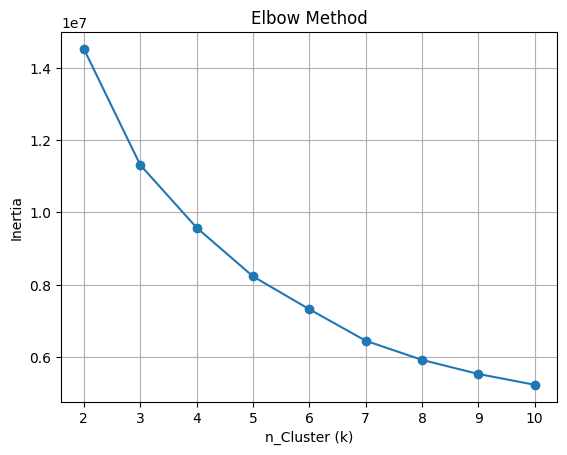

In [ ]:
# 1. 사용할 데이터 준비 (수치형 변수만 추출)
X = train_df[numeric_columns].copy()

# 결측치 제거
X = X.dropna()

# 2. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 최적 클러스터 수 찾기 (Elbow Method)
inertia = []
k_range = range(2, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('n_Cluster (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()


         이용금액_R3M_신용체크       청구금액_R6M   이용금액_R3M_신용      청구금액_R3M  \
Cluster                                                             
0         17797.434638   40568.628207  16060.670512  19531.705111   
1         48423.974294  145355.374779  46835.175669  70091.523182   
2         80844.322655  116502.748247  78753.140557  58040.318692   
3         22248.311001   30748.089005  19029.227603  14351.665222   
4          2572.722156    5730.378870   1651.220847   2353.263744   

              청구금액_B0    _1순위카드이용금액  이용카드수_신용체크    _2순위카드이용금액  _1순위카드이용건수  \
Cluster                                                                     
0         6249.725787  15459.922872    1.184979     93.619454   63.923698   
1        22536.605670  37960.277438    1.605335   3519.428056  100.706755   
2        19313.879128  41621.989689    3.220841  27703.012563  137.158538   
3         4564.023490  10552.027577    2.463569   8231.598045   40.772521   
4          728.063673   1846.145412    0.685845     54

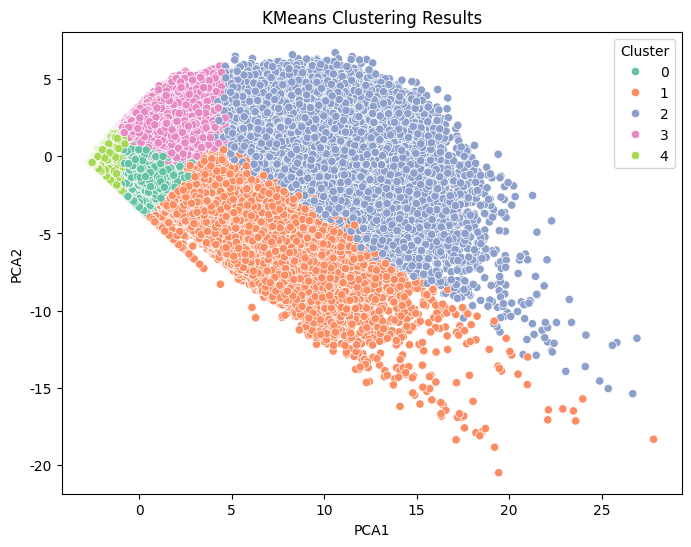

In [ ]:
# k=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 프로파일링
profile = X.groupby('Cluster').mean()
print(profile)

# 시각화 (예: PCA를 활용한 2D 표현)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X['PCA1'] = X_pca[:, 0]
X['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=X, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('KMeans Clustering Results')

plt.show()

In [ ]:
train_df['Cluster'] = kmeans.labels_

In [ ]:
pd.crosstab(train_df['Cluster'], train_df['Segment'], normalize='index')

Segment,C,D,E
Cluster,,,
0,0.025918,0.159974,0.814108
1,0.309941,0.423351,0.266708
2,0.315695,0.502074,0.182231
3,0.041812,0.206040,0.752149
4,0.007884,0.035863,0.956253


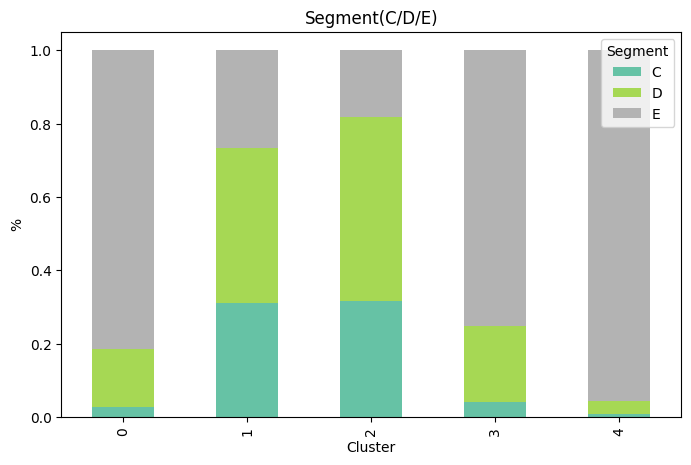

In [ ]:

cluster_segment_dist = pd.crosstab(train_df['Cluster'], train_df['Segment'], normalize='index')

cluster_segment_dist.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Segment(C/D/E)')
plt.xlabel('Cluster')
plt.ylabel('%')
plt.legend(title='Segment')
plt.show()

In [ ]:
### 인코딩한다
train_df['이용금액대'] = train_df['이용금액대'].factorize()[0]
train_df['인입횟수_ARS_R6M'] = train_df['인입횟수_ARS_R6M'].factorize()[0]
train_df['방문횟수_앱_R6M'] = train_df['방문횟수_앱_R6M'].factorize()[0]
train_df['방문횟수_PC_R6M'] = train_df['방문횟수_PC_R6M'].factorize()[0]
train_df['방문일수_PC_R6M'] = train_df['방문일수_PC_R6M'].factorize()[0]

### VIF 검사

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
# 독립변수만 가져온다.
vif_X = train_df[[
 '이용금액_R3M_신용체크',
 '청구금액_R6M',
 '이용카드수_신용체크',
 '_1순위카드이용건수',
 '_2순위카드이용건수',
 '이용금액대',
 '인입횟수_ARS_R6M',
 '방문횟수_앱_R6M',
 '방문횟수_PC_R6M']]

# vif를 계산하기 위해 사용할 상수항을 추가한다.
vif_X2 = sm.add_constant(vif_X)

# vif를 계산한다
vif = pd.DataFrame()
vif['변수'] = vif_X2.columns
vif['VIF'] = [variance_inflation_factor(vif_X2.values, i) for i in range(vif_X2.shape[1])]
vif

,변수,VIF
0,const,42.535887
1,이용금액_R3M_신용체크,4.203566
2,청구금액_R6M,2.193675
3,이용카드수_신용체크,2.421103
4,_1순위카드이용건수,2.016230
5,_2순위카드이용건수,2.480561
6,이용금액대,1.480793
7,인입횟수_ARS_R6M,1.050509
8,방문횟수_앱_R6M,1.088369
9,방문횟수_PC_R6M,1.051878


이용금액_R3M_신용	83.555794 VIF가 가장 높아 먼저 제거
청구금액_R3M	19.728763 두번째 제거
_2순위카드이용금액	15.187842 세번째
방문일수_PC_R6M	10.522015 네번쨰
_1순위카드이용금액	10.355018
이용카드수_신용	8.707343
청구금액_B0	5.658310

In [17]:
all_df = train_df[['ID', '기준년월', 'Segment',
 '이용금액_R3M_신용체크',
 '청구금액_R6M',
 '이용카드수_신용체크',
 '_1순위카드이용건수',
 '_2순위카드이용건수',
 '이용금액대',
 '인입횟수_ARS_R6M',
 '방문횟수_앱_R6M',
 '방문횟수_PC_R6M']]

In [18]:
all_df.to_parquet('/content/drive/MyDrive/abcde/cde_train_vif&clustering.parquet')

In [ ]:
# 수치형변수
numeric_columns = [ '이용금액_R3M_신용체크',
 '청구금액_R6M',
 '이용카드수_신용체크',
 '_1순위카드이용건수',
 '_2순위카드이용건수']

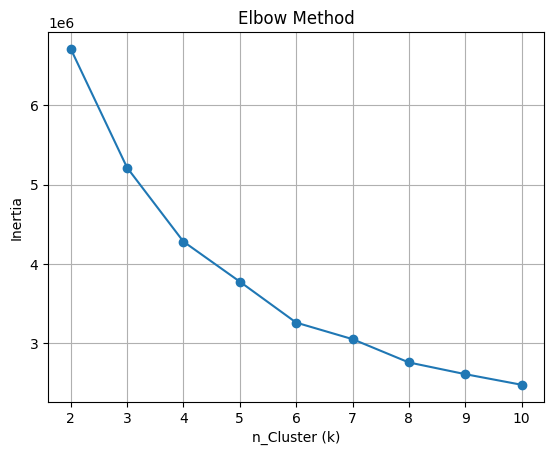

In [ ]:
# 1. 사용할 데이터 준비 (수치형 변수만 추출)
X = train_df[numeric_columns].copy()

# 결측치 제거
X = X.dropna()

# 2. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 최적 클러스터 수 찾기 (Elbow Method)
inertia = []
k_range = range(2, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('n_Cluster (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

         이용금액_R3M_신용체크       청구금액_R6M  이용카드수_신용체크  _1순위카드이용건수  _2순위카드이용건수
Cluster                                                                  
0         20918.362757   47097.900826    1.143155   85.973063    0.925211
1         43014.827419   56403.088008    2.700200   87.823178   59.921279
2          3254.852426    9058.741221    0.628020    8.575655    0.115501
3         87178.758711  127567.682639    3.272474  155.703623  113.299298
4         14614.860554   20701.337096    2.244736   18.115353   20.218377
5         49503.072660  186769.668474    1.560744   90.972858   12.087040


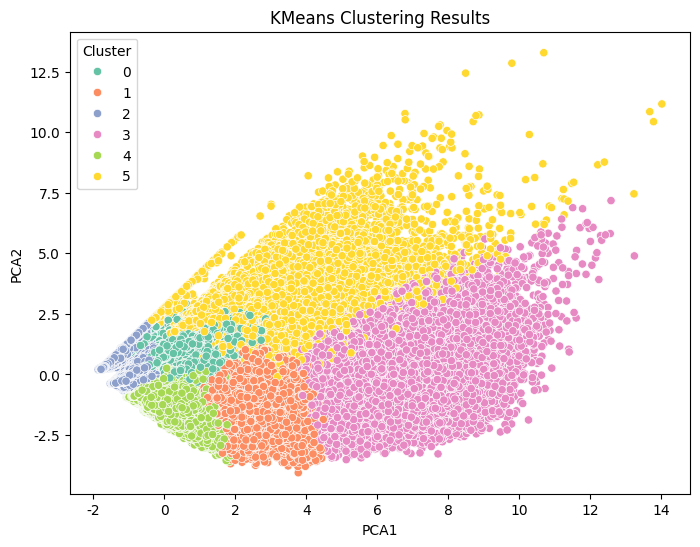

In [ ]:
# k=6
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
X['Cluster'] = kmeans.fit_predict(X_scaled)

# 클러스터별 프로파일링
profile = X.groupby('Cluster').mean()
print(profile)

# 시각화 (예: PCA를 활용한 2D 표현)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X['PCA1'] = X_pca[:, 0]
X['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=X, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('KMeans Clustering Results')

plt.show()

In [ ]:
train_df['Cluster'] = kmeans.labels_

In [ ]:
pd.crosstab(train_df['Cluster'], train_df['Segment'], normalize='index')

Segment,C,D,E
Cluster,,,
0,0.032311,0.197859,0.769830
1,0.099766,0.390027,0.510207
2,0.008457,0.036919,0.954624
3,0.364698,0.488978,0.146323
4,0.029993,0.145236,0.824771
5,0.408792,0.380510,0.210699


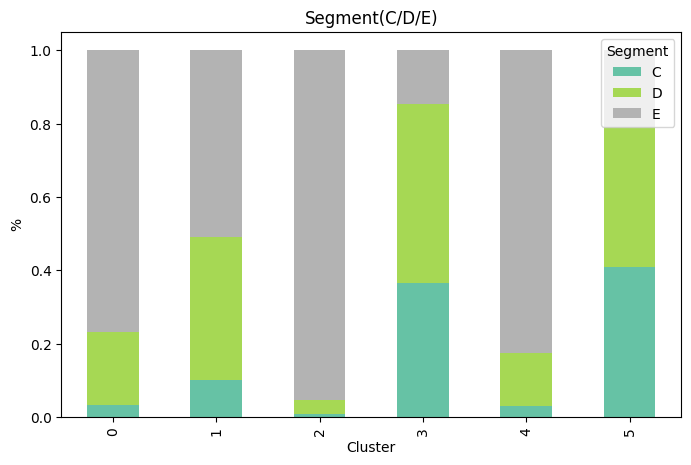

In [ ]:

cluster_segment_dist = pd.crosstab(train_df['Cluster'], train_df['Segment'], normalize='index')

cluster_segment_dist.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Segment(C/D/E)')
plt.xlabel('Cluster')
plt.ylabel('%')
plt.legend(title='Segment')
plt.show()

In [19]:
vif_df = pd.read_parquet('/content/drive/MyDrive/abcde/cde_train_vif&clustering.parquet')

In [21]:
plus_df = pd.read_parquet('/content/drive/MyDrive/abcde/cde추가할컬럼_df.parquet')

In [20]:
vif_df

,ID,기준년월,Segment,이용금액_R3M_신용체크,청구금액_R6M,이용카드수_신용체크,_1순위카드이용건수,_2순위카드이용건수,이용금액대,인입횟수_ARS_R6M,방문횟수_앱_R6M,방문횟수_PC_R6M
0,TRAIN_000000,201807,D,196,88693,1,26,0,01.100만원+,10회 이상,1회 이상,1회 이상
1,TRAIN_000001,201807,E,13475,16861,1,46,0,03.30만원+,1회 이상,1회 이상,1회 이상
2,TRAIN_000002,201807,C,23988,165221,1,28,0,01.100만원+,1회 이상,30회 이상,10회 이상
3,TRAIN_000003,201807,D,3904,127371,1,1,0,01.100만원+,10회 이상,1회 이상,1회 이상
4,TRAIN_000004,201807,E,1190,155,1,-2,0,09.미사용,1회 이상,1회 이상,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...
2398879,TRAIN_399995,201812,E,10755,0,1,3,0,09.미사용,1회 이상,1회 이상,1회 이상
2398880,TRAIN_399996,201812,D,27636,99849,1,38,0,01.100만원+,1회 이상,1회 이상,1회 이상
2398881,TRAIN_399997,201812,C,23187,41073,1,33,0,02.50만원+,1회 이상,1회 이상,1회 이상
2398882,TRAIN_399998,201812,E,0,0,0,-2,0,09.미사용,1회 이상,1회 이상,1회 이상


In [10]:
plus_df

,ID,기준년월,Segment,정상청구원금_B5M,이용금액_일시불_R12M,연체입금원금_B5M,연체입금원금_B2M,입회일자_신용
0,TRAIN_000000,201807,D,14958,20667,5752,398,20130101
1,TRAIN_000001,201807,E,3367,54341,821,0,20170801
2,TRAIN_000002,201807,C,23963,55656,7014,7378,20080401
3,TRAIN_000003,201807,D,19614,10753,11196,6128,20160501
4,TRAIN_000004,201807,E,0,-2129,0,272,20180601
...,...,...,...,...,...,...,...,...
2398879,TRAIN_399995,201812,E,0,0,0,0,20010701
2398880,TRAIN_399996,201812,D,23742,148106,1910,4080,20170701
2398881,TRAIN_399997,201812,C,4125,52233,856,755,20090501
2398882,TRAIN_399998,201812,E,507,0,507,0,20130101


In [22]:
all_df = vif_df.merge(plus_df, on=['ID','기준년월','Segment'])
all_df

,ID,기준년월,Segment,이용금액_R3M_신용체크,청구금액_R6M,이용카드수_신용체크,_1순위카드이용건수,_2순위카드이용건수,이용금액대,인입횟수_ARS_R6M,방문횟수_앱_R6M,방문횟수_PC_R6M,정상청구원금_B5M,이용금액_일시불_R12M,연체입금원금_B5M,연체입금원금_B2M,입회일자_신용
0,TRAIN_000000,201807,D,196,88693,1,26,0,01.100만원+,10회 이상,1회 이상,1회 이상,14958,20667,5752,398,20130101
1,TRAIN_000001,201807,E,13475,16861,1,46,0,03.30만원+,1회 이상,1회 이상,1회 이상,3367,54341,821,0,20170801
2,TRAIN_000002,201807,C,23988,165221,1,28,0,01.100만원+,1회 이상,30회 이상,10회 이상,23963,55656,7014,7378,20080401
3,TRAIN_000003,201807,D,3904,127371,1,1,0,01.100만원+,10회 이상,1회 이상,1회 이상,19614,10753,11196,6128,20160501
4,TRAIN_000004,201807,E,1190,155,1,-2,0,09.미사용,1회 이상,1회 이상,1회 이상,0,-2129,0,272,20180601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398879,TRAIN_399995,201812,E,10755,0,1,3,0,09.미사용,1회 이상,1회 이상,1회 이상,0,0,0,0,20010701
2398880,TRAIN_399996,201812,D,27636,99849,1,38,0,01.100만원+,1회 이상,1회 이상,1회 이상,23742,148106,1910,4080,20170701
2398881,TRAIN_399997,201812,C,23187,41073,1,33,0,02.50만원+,1회 이상,1회 이상,1회 이상,4125,52233,856,755,20090501
2398882,TRAIN_399998,201812,E,0,0,0,-2,0,09.미사용,1회 이상,1회 이상,1회 이상,507,0,507,0,20130101


In [23]:
all_df.columns

Index(['ID', '기준년월', 'Segment', '이용금액_R3M_신용체크', '청구금액_R6M', '이용카드수_신용체크',
       '_1순위카드이용건수', '_2순위카드이용건수', '이용금액대', '인입횟수_ARS_R6M', '방문횟수_앱_R6M',
       '방문횟수_PC_R6M', '정상청구원금_B5M', '이용금액_일시불_R12M', '연체입금원금_B5M',
       '연체입금원금_B2M', '입회일자_신용'],
      dtype='object')

In [24]:
all_df.to_parquet('/content/drive/MyDrive/abcde/cde_train_final.parquet')